# AI in Business – Midterm (Student)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,roc_auc_score


## Load dataset and perform EDA

In [6]:
df=pd.read_csv('retail_ai_midterm_dataset.csv')
df.head()


,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,membership_years,website_visits_month,returns_rate,churn
0,1,65,148317,80,18,486,8,46,0.25,0
1,2,22,110847,66,16,49,9,24,0.45,0
2,3,43,146771,8,32,66,6,15,0.16,0
3,4,72,79324,98,36,394,2,38,0.43,0
4,5,21,60594,30,52,650,7,22,0.15,0


In [11]:
df.shape

(800, 10)

In [8]:
df.describe(include='all')

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,membership_years,website_visits_month,returns_rate,churn
count,800.0000,800.000000,800.00000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000
mean,400.5000,46.570000,89068.26000,50.242500,29.497500,334.473750,5.41625,25.237500,0.250837,0.217500
std,231.0844,16.575993,36545.86473,28.433286,17.371592,197.835925,3.43296,14.511351,0.146942,0.412804
min,1.0000,18.000000,25088.00000,1.000000,1.000000,5.000000,0.00000,0.000000,0.000000,0.000000
25%,200.7500,32.000000,58244.25000,26.000000,14.000000,171.000000,2.00000,12.000000,0.120000,0.000000
50%,400.5000,47.000000,89941.00000,51.000000,29.000000,326.500000,5.00000,26.000000,0.245000,0.000000
75%,600.2500,61.000000,121553.25000,74.000000,45.000000,496.250000,8.00000,38.000000,0.380000,0.000000
max,800.0000,74.000000,149958.00000,99.000000,59.000000,697.000000,11.00000,49.000000,0.500000,1.000000


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            800 non-null    int64  
 1   age                    800 non-null    int64  
 2   annual_income          800 non-null    int64  
 3   spending_score         800 non-null    int64  
 4   purchase_frequency     800 non-null    int64  
 5   avg_transaction_value  800 non-null    int64  
 6   membership_years       800 non-null    int64  
 7   website_visits_month   800 non-null    int64  
 8   returns_rate           800 non-null    float64
 9   churn                  800 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 62.6 KB


In [9]:
df.isnull().sum()

customer_id              0
age                      0
annual_income            0
spending_score           0
purchase_frequency       0
avg_transaction_value    0
membership_years         0
website_visits_month     0
returns_rate             0
churn                    0
dtype: int64

# Perform EDA

In [10]:
df["churn"].value_counts()

churn
0    626
1    174
Name: count, dtype: int64

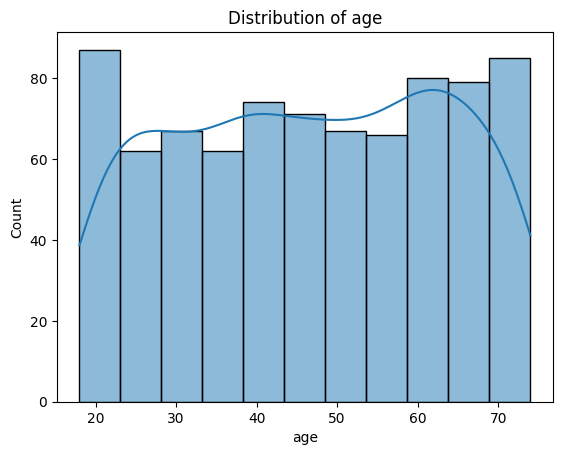

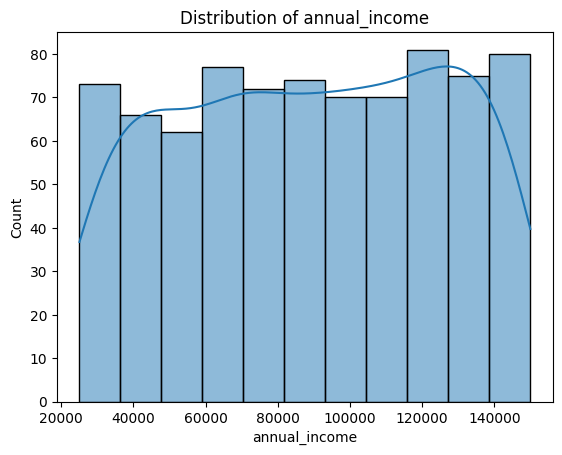

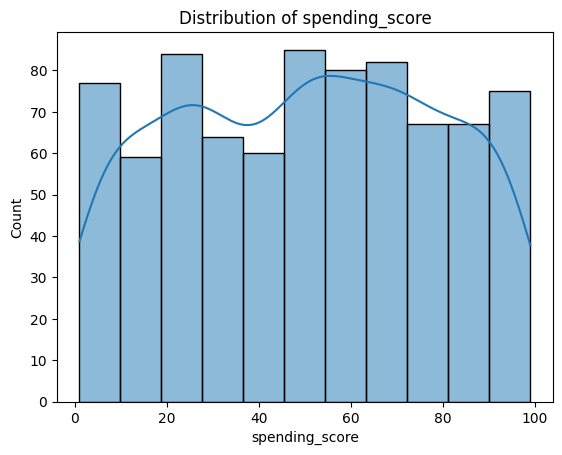

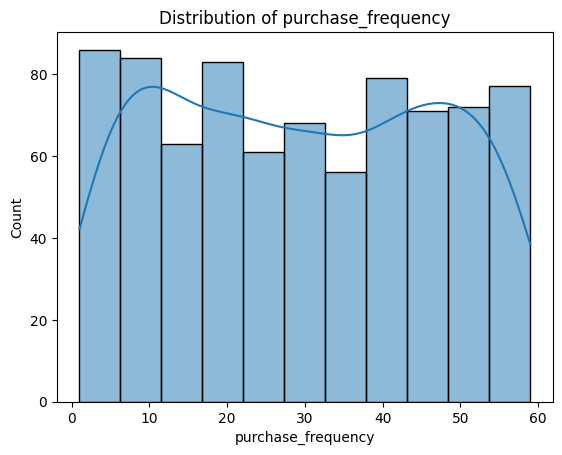

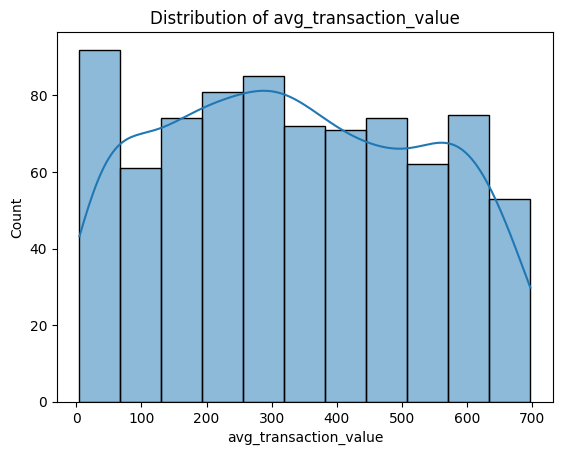

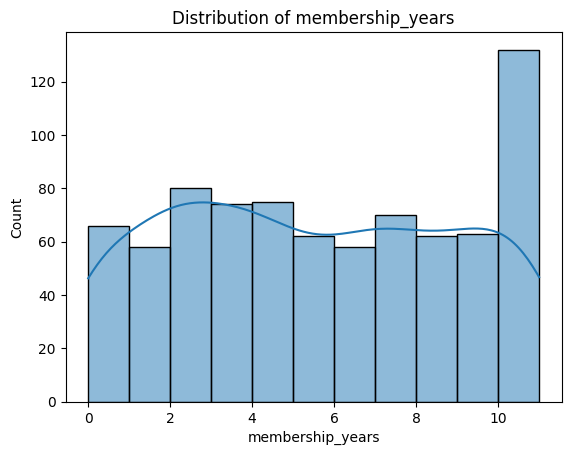

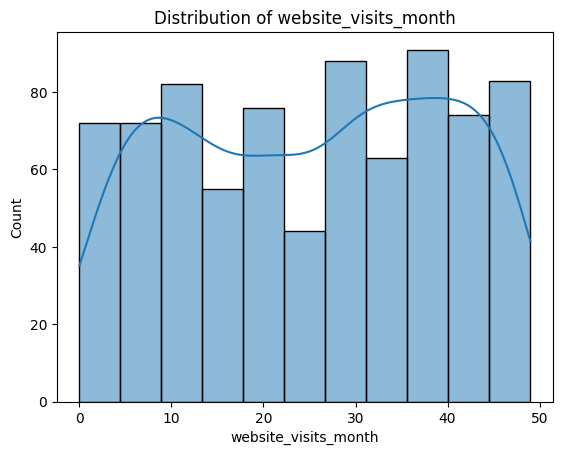

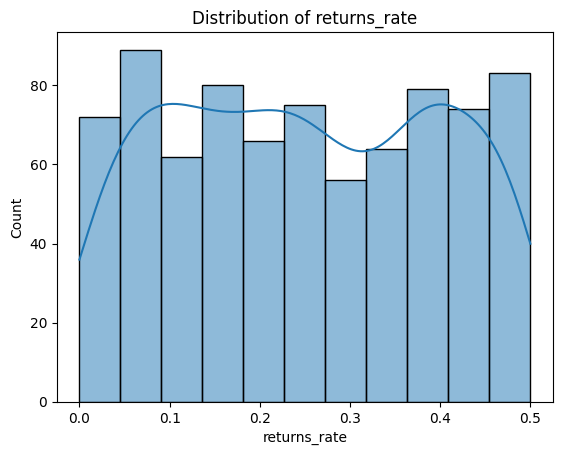

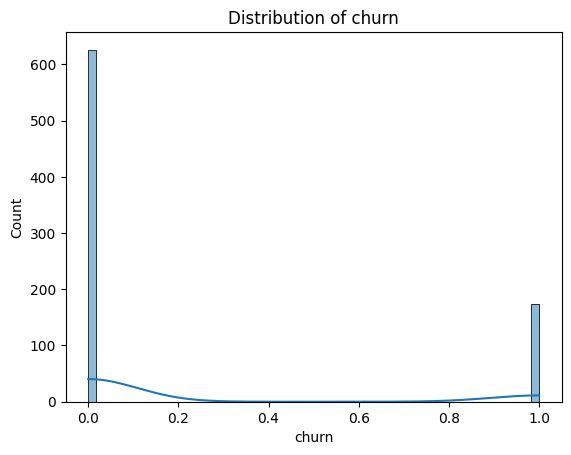

In [17]:
# Explore customer distribution
columns = df.columns[1:]

for col in columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### The histograms provide an overview of the distribution of customer characteristics in the dataset. The **churn variable is imbalanced**, with most customers remaining active and a smaller proportion having churned, which is important to consider during model evaluation. The **age distribution** shows customers ranging roughly from 18 to 75 years, indicating a diverse demographic base. **Annual income** varies widely between about $20,000 and $150,000, suggesting customers from different economic backgrounds. Behavioral variables such as **purchase frequency, website visits, and spending score** are broadly distributed, reflecting varying levels of customer engagement and spending habits. **Average transaction value** also shows substantial variation, indicating differences in purchasing power. Additionally, **membership years** range from new to long-term customers, while **returns rate** varies across customers. Overall, the distributions suggest sufficient variability in the features, which is beneficial for training machine learning models to predict churn and identify key behavioral drivers.


## Bivariate Analysis

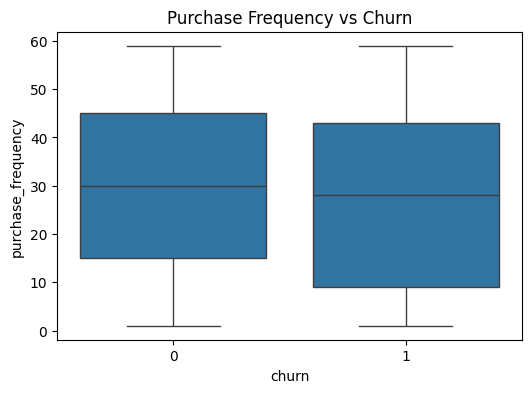

In [18]:
#Purchase Frequency

plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='purchase_frequency', data=df)
plt.title("Purchase Frequency vs Churn")
plt.show()

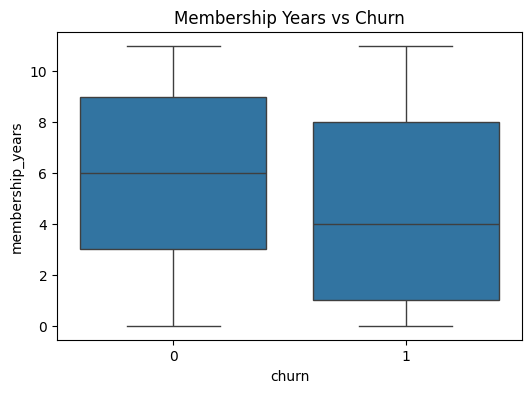

In [19]:
# Membership Years
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='membership_years', data=df)
plt.title("Membership Years vs Churn")
plt.show()

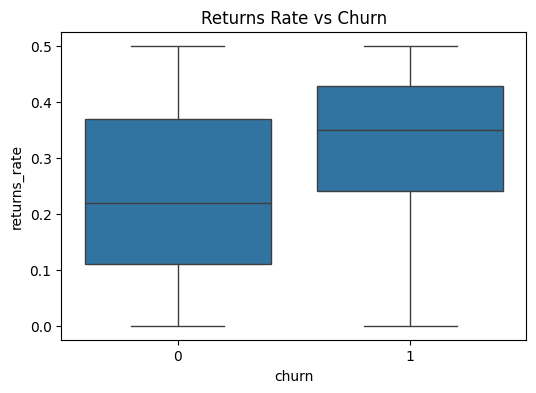

In [21]:
# Returns Rate
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='returns_rate', data=df)
plt.title("Returns Rate vs Churn")
plt.show()

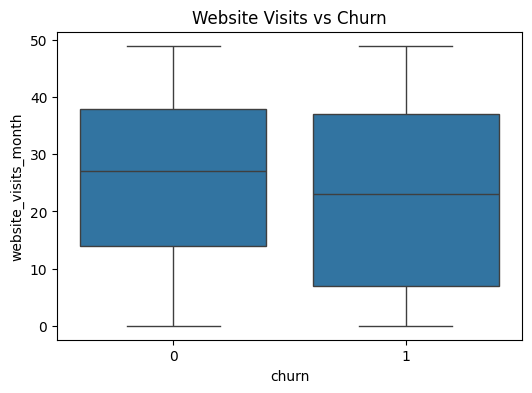

In [22]:
# Website visits
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='website_visits_month', data=df)
plt.title("Website Visits vs Churn")
plt.show()



### Bivariate Analysis: Key Features vs Churn

To identify potential drivers of customer churn, four key behavioral variables were analyzed against the churn variable using boxplots: **website visits per month, returns rate, membership years, and purchase frequency**.

The results show noticeable differences between churned and non-churned customers. Customers who churn tend to have **slightly fewer website visits per month**, suggesting lower engagement with the platform. In contrast, churned customers generally exhibit a **higher returns rate**, which may indicate dissatisfaction with products or services.

Membership duration also shows a clear pattern: customers who churn typically have **fewer membership years**, suggesting that newer customers are more likely to leave than long-term customers. Similarly, churned customers tend to have **lower purchase frequency**, indicating reduced purchasing activity before leaving.

Overall, these patterns suggest that **customer engagement, loyalty, purchasing behavior, and satisfaction** are important factors influencing churn and are likely to be strong predictors in the churn prediction model.


## Multivariate Analysis

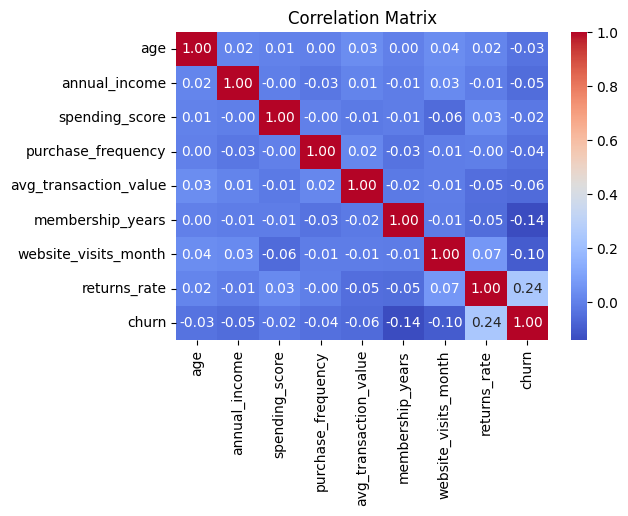

In [27]:
plt.figure(figsize=(6,4))

corr = df.drop(columns=['customer_id']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

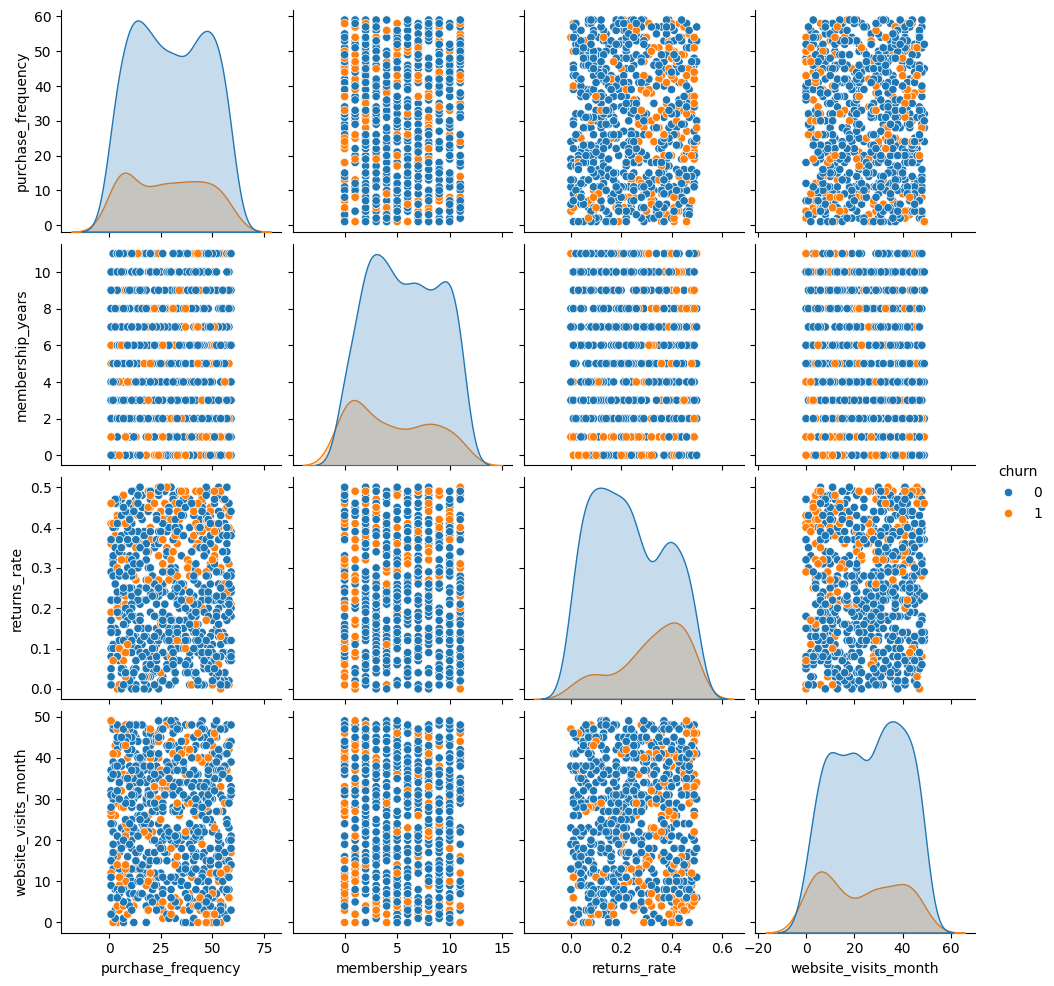

In [24]:
features = ['purchase_frequency',
            'membership_years',
            'returns_rate',
            'website_visits_month',
            'churn']

sns.pairplot(df[features], hue='churn')

plt.show()


# Multivariate Analysis

To further understand the relationships among variables influencing customer churn, a **pairplot and correlation matrix** were used to analyze multiple features simultaneously.

The **correlation matrix** shows that most variables have weak correlations with each other, indicating low multicollinearity within the dataset. However, some meaningful relationships with churn are observed. **Returns rate has the strongest positive correlation with churn (0.24)**, suggesting that customers who return products more frequently are more likely to churn. Conversely, **membership years (-0.14)** and **website visits per month (-0.10)** show negative correlations with churn, indicating that customers who have been members longer and engage more with the platform tend to remain active.

The **pairplot** further supports these findings by visualizing relationships between key behavioral variables and churn. Churned customers appear more concentrated in areas with **higher returns rates, fewer membership years, lower website engagement, and slightly lower purchase frequency**.

Overall, the multivariate analysis highlights **customer satisfaction, engagement, and loyalty** as important factors influencing churn and provides insight into variables that will be valuable for predictive modeling.


## Train Logistic Regression and Random Forest models

In [28]:
X = df.drop(columns=['customer_id','churn'])
y = df['churn']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=2000, class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.88      0.66      0.75       129
           1       0.30      0.61      0.40        31

    accuracy                           0.65       160
   macro avg       0.59      0.64      0.58       160
weighted avg       0.76      0.65      0.68       160



## Random Forest

## Perform KMeans clustering and PCA visualization